# Final Project for Big data course
### Analasis of the relations of demographics in israel and voting patterns

In [38]:
import re
import time
import pandas as pd
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

# Progress bar (with fallback if tqdm not installed)
try:
    from tqdm import tqdm
except Exception:
    def tqdm(iterable=None, total=None, desc=None, unit=None):
        print(f"{desc or 'Progress'}: starting ({total if total is not None else '?' } {unit or ''})")
        for i, item in enumerate(iterable, 1):
            if i == 1 or (total and (i % max(1, total // 10) == 0)) or (total and i == total):
                print(f"{desc or 'Progress'}: {i}/{total if total is not None else '?'} {unit or ''}")
            yield item

def normalize_city_id(v):
    if pd.isna(v):
        return None
    s = str(v).strip()
    try:
        f = float(s)
        if f.is_integer():
            return str(int(f))
        return s
    except Exception:
        return s

def parse_location_and_value(inner_html: str):
    text = BeautifulSoup(inner_html or "", "html.parser").get_text(" ", strip=True)
    if not text:
        return None, None
    phrase = " קלפי מספר"
    location = text.split(phrase)[0].strip()
    m = re.search(r"(\d+)\s*$", text)
    value = m.group(1) if m else None
    return (location if location else None), value

def collect_options_from_input(driver, wait):
    try:
        inp = wait.until(
            EC.presence_of_element_located(
                (By.CSS_SELECTOR, "input.awesomplete.dropdown-input.PollingStationList")
            )
        )
    except Exception:
        return []
    # Prefer options in a linked datalist
    list_id = inp.get_attribute("list")
    if list_id:
        opts = driver.find_elements(By.CSS_SELECTOR, f"#{list_id} > option")
        if opts:
            return [(o.get_attribute("value"), o.get_attribute("innerHTML")) for o in opts]
    # Fallback: sometimes a select exists with same logical list
    sel_opts = driver.find_elements(By.CSS_SELECTOR, "select.PollingStationList option")
    if sel_opts:
        return [(o.get_attribute("value"), o.get_attribute("innerHTML")) for o in sel_opts]
    # Last resort: parse any option tags in the DOM
    soup = BeautifulSoup(driver.page_source, "lxml")
    found = []
    for opt in soup.select("option"):
        val = opt.get("value")
        inner_html = "".join(str(c) for c in opt.contents)
        found.append((val, inner_html))
    return found

def main():
    # 1) Load Excel and extract unique city IDs from column B (rows 4..3282) where column C is not null
    excel_path = "census.xlsx"
    df_x = pd.read_excel(excel_path, header=None, engine="openpyxl")  # No header; A=0,B=1,C=2
    start_row, end_row = 4, 3282  # Excel 1-indexed inclusive
    df_slice = df_x.iloc[start_row - 1 : end_row].copy()
    df_slice = df_slice[df_slice[2].notna()]  # only rows where column C has a value
    city_ids = sorted(
        {cid for cid in (normalize_city_id(v) for v in df_slice[1].dropna().unique()) if cid}
    )

    # 2) Set up Selenium (headless Chrome)
    chrome_options = webdriver.ChromeOptions()
    chrome_options.add_argument("--headless=new")
    chrome_options.add_argument("--disable-gpu")
    chrome_options.add_argument("--no-sandbox")
    chrome_options.add_argument("--window-size=1400,1000")
    chrome_options.add_argument("--lang=he-IL")
    chrome_options.add_argument("--disable-dev-shm-usage")
    chrome_options.add_argument(
        "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
    )

    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=chrome_options)
    wait = WebDriverWait(driver, 15)

    rows = []
    base = "https://votes25.bechirot.gov.il/ballotresults?cityID="

    try:
        for city in tqdm(city_ids, total=len(city_ids), desc="Cities", unit="city"):
            url = f"{base}{city}"
            try:
                driver.get(url)
            except Exception:
                continue

            # Give the page a moment for dynamic lists to populate
            time.sleep(1.0)

            try:
                pairs = collect_options_from_input(driver, wait)
            except Exception:
                pairs = []

            added = 0
            for val_attr, inner_html in pairs:
                if (val_attr or "").strip() == "0":
                    continue
                location, value_num = parse_location_and_value(inner_html or "")
                if not value_num or not location:
                    continue
                rows.append(
                    {
                        "city": str(city),
                        "location": location,
                        "value": str(value_num),
                    }
                )
                added += 1
            # Per-city progress line without breaking the bar
            try:
                tqdm.write(f"City {city}: options={len(pairs)} added={added}")
            except Exception:
                pass
    finally:
        driver.quit()

    polling_locations = pd.DataFrame(rows, columns=["city", "location", "value"])
    print(f"Collected {len(polling_locations)} polling locations across {len(city_ids)} cities.")
    if not polling_locations.empty:
        print(polling_locations.head(10).to_string(index=False))
    return polling_locations

if __name__ == "__main__":
    polling_locations = main()

Cities:   1%|          | 1/140 [00:02<06:38,  2.86s/city]

City 1015: options=1251 added=33


Cities:   1%|▏         | 2/140 [00:04<04:19,  1.88s/city]

City 1020: options=1248 added=30


Cities:   2%|▏         | 3/140 [00:05<03:32,  1.55s/city]

City 1031: options=1260 added=42


Cities:   2%|▏         | 3/140 [00:06<04:47,  2.10s/city]


KeyboardInterrupt: 

In [7]:
import geopandas as gpd
import fiona
from shapely.geometry import Point
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import os
import zipfile
import tempfile
import pandas as pd

# 2) Read polygons from geo.gdb.zip
def read_polygons_from_filegdb_zip(zip_path: str) -> gpd.GeoDataFrame:
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"Missing file: {zip_path}")
    zip_uri = f"zip://{os.path.abspath(zip_path)}"
    try:
        layers = fiona.listlayers(zip_uri)
    except Exception:
        layers = []
    gdf = None
    if layers:
        for lyr in layers:
            try:
                tmp = gpd.read_file(zip_uri, layer=lyr)
                if "STAT_2022" in tmp.columns:
                    gdf = tmp
                    break
                if gdf is None:
                    gdf = tmp
            except Exception:
                continue
    if gdf is None:
        with tempfile.TemporaryDirectory() as td:
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(td)
            gdb_dirs = [os.path.join(td, d) for d in os.listdir(td) if d.lower().endswith(".gdb")]
            if not gdb_dirs:
                raise RuntimeError("No .gdb directory found inside the zip.")
            gdb_path = gdb_dirs[0]
            layers = fiona.listlayers(gdb_path)
            for lyr in layers:
                try:
                    tmp = gpd.read_file(gdb_path, layer=lyr)
                    if "STAT_2022" in tmp.columns:
                        gdf = tmp
                        break
                    if gdf is None:
                        gdf = tmp
                except Exception:
                    continue
    if gdf is None or gdf.empty:
        raise RuntimeError("Failed to read polygons from geo.gdb.zip")
    if gdf.geometry is None or gdf.geometry.isna().all():
        if "Shape" in gdf.columns:
            gdf = gdf.set_geometry("Shape")
        else:
            raise RuntimeError("No valid geometry column found in polygons.")
    # Normalize expected columns (case-insensitive)
    def resolve_col(df, target):
        for c in df.columns:
            if c.lower() == target.lower():
                return c
        return None
    col_2022 = resolve_col(gdf, "STAT_2022")
    col_semel = resolve_col(gdf, "SEMEL_YISHUV")
    col_shem  = resolve_col(gdf, "SHEM_YISHUV_HEB")
    if not col_2022:
        raise RuntimeError("Field 'STAT_2022' not found in polygons layer.")
    # Keep geometry + available admin columns
    keep = [c for c in [col_2022, col_semel, col_shem] if c]
    gdf = gdf[keep + [gdf.geometry.name]].rename(
        columns={col_2022: "STAT_2022", **({col_semel: "SEMEL_YISHUV"} if col_semel else {}), **({col_shem: "SHEM_YISHUV_HEB"} if col_shem else {})}
    )
    return gdf

polygons = read_polygons_from_filegdb_zip("geo.gdb.zip")
def _norm_city_key(v):
    try:
        s = str(v).strip()
        f = float(s)
        return str(int(f)) if f.is_integer() else s
    except Exception:
        return str(v).strip() if v is not None else None

if "SEMEL_YISHUV" in polygons.columns and "SHEM_YISHUV_HEB" in polygons.columns:
    tmp_poly = polygons.dropna(subset=["SEMEL_YISHUV", "SHEM_YISHUV_HEB"]).copy()
    tmp_poly["_city_key"] = tmp_poly["SEMEL_YISHUV"].map(_norm_city_key)
    city_map = tmp_poly.drop_duplicates("_city_key").set_index("_city_key")["SHEM_YISHUV_HEB"].to_dict()
else:
    city_map = {}
# 3) Geocode polling locations with Nominatim (rate limited + cache)
# Compose a query using location + city + country for better precision
polling_locations["_city_key"] = polling_locations["city"].map(_norm_city_key)
polling_locations["city_he"]   = polling_locations["_city_key"].map(city_map)
# ...existing code...
def build_query(row):
    city_key = _norm_lookup_key(row.get("city"))
    original_value_key = _norm_lookup_key(row.get("value"))

    # Remap value via expb.csv: (city D, value B) -> value E
    remapped_value_key = value_remap.get((city_key, original_value_key), original_value_key)

    # Lookup address via adresses.xlsx using (city, remapped value)
    addr = address_map.get((city_key, remapped_value_key))
    parts = [addr] if addr else []
    # Use Hebrew city name from polygons via SEMEL_YISHUV lookup
    if pd.notna(row.get("city_he", None)) and str(row["city_he"]).strip():
        parts.append(str(row["city_he"]))
    parts.append("Israel")
    return ", ".join([p for p in parts if p])

import pandas as pd

# Open the adresses.xlsx file and build (city,value) -> address lookup
try:
    addresses_df = pd.read_excel("adresses.xlsx", header=None, engine="openpyxl")
except Exception as e:
    raise RuntimeError(f"Failed to open 'adresses.xlsx': {e}")

# Helper to normalize city/value keys
def _norm_lookup_key(v):
    if pd.isna(v):
        return None
    s = str(v).strip()
    try:
        f = float(s)
        return str(int(f)) if f.is_integer() else s
    except Exception:
        return s

# Expect columns: C=2 (city number), E=4 ('value'), G=6 (address)
if addresses_df.shape[1] <= 6:
    raise RuntimeError("adresses.xlsx must have at least 7 columns (need C, F, G).")

addr_tmp = addresses_df.dropna(subset=[2, 5, 6]).copy()
addr_tmp["_city_key"] = addr_tmp[2].map(_norm_lookup_key)
addr_tmp["_value_key"] = addr_tmp[5].map(_norm_lookup_key)
addr_tmp["address"] = addr_tmp[6].astype(str).str.strip()
addr_tmp = addr_tmp[
    addr_tmp["_city_key"].notna() & addr_tmp["_value_key"].notna() & (addr_tmp["address"] != "")
]
address_map = (
    addr_tmp.drop_duplicates(["_city_key", "_value_key"])
    .set_index(["_city_key", "_value_key"])["address"]
    .to_dict()
)
try:
    expb_df = pd.read_csv("expb.csv", header=None)
except Exception as e:
    raise RuntimeError(f"Failed to open 'expb.csv': {e}")

if expb_df.shape[1] <= 5:
    raise RuntimeError("expb.csv must have at least 6 columns (need B, D, F).")

expb_tmp = expb_df.dropna(subset=[3, 1, 5]).copy()  # D=3, B=1, F=4
expb_tmp["_city_key"]   = expb_tmp.iloc[:, 3].map(_norm_lookup_key)
expb_tmp["_valueB_key"] = expb_tmp.iloc[:, 1].map(_norm_lookup_key)
expb_tmp["_valueF_key"] = expb_tmp.iloc[:, 5].map(_norm_lookup_key)
expb_tmp = expb_tmp[expb_tmp["_city_key"].notna() & expb_tmp["_valueB_key"].notna() & expb_tmp["_valueF_key"].notna()]

value_remap = (
    expb_tmp.drop_duplicates(["_city_key", "_valueB_key"])
            .set_index(["_city_key", "_valueB_key"])["_valueF_key"]
            .to_dict()
)

# Geocoding: use the address from adresses.xlsx matched by (city, value)
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(user_agent="israel_census_voting_project/1.0")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1, swallow_exceptions=True)

_geocode_cache = {}

def geocode_row(row):
    addr = build_query(row)
    #add the city to the address
    if not addr:
        return None, None
    if addr in _geocode_cache and _geocode_cache[addr] != (None, None):
        return _geocode_cache[addr]
    loc = geocode(addr, country_codes="il", addressdetails=False)
    if loc is None:
        _geocode_cache[addr] = (None, None)
        return None, None
    res = (loc.latitude, loc.longitude)
    _geocode_cache[addr] = res
    return res

# Apply with progress
try:
    from tqdm import tqdm
    tqdm.pandas(desc="Geocoding (addresses)")
    geo_series = polling_locations.progress_apply(
        lambda r: pd.Series(geocode_row(r), index=["lat", "lon"]), axis=1
    )
except Exception:
    geo_series = polling_locations.apply(
        lambda r: pd.Series(geocode_row(r), index=["lat", "lon"]), axis=1
    )

polling_points_df = pd.concat([polling_locations.reset_index(drop=True), geo_series], axis=1)
polling_points_df = polling_points_df.dropna(subset=["lat", "lon"]).copy()

# 4) Build GeoDataFrames and align CRS
points_gdf = gpd.GeoDataFrame(
    polling_points_df,
    geometry=[Point(lon, lat) for lat, lon in zip(polling_points_df["lat"], polling_points_df["lon"])],
    crs="EPSG:4326",
)

poly_crs = polygons.crs if polygons.crs is not None else "EPSG:4326"
polygons = polygons.set_crs(poly_crs, allow_override=True)
points_proj = points_gdf.to_crs(poly_crs)

# 5) Spatial join: points within polygons
# Using predicate='within' adheres to "inside the polygon"
joined = gpd.sjoin(points_proj, polygons[["STAT_2022", "geometry"]], how="inner", predicate="within")

# 6) Build the requested dataframe
polling_in_areas = (
    joined.rename(columns={"STAT_2022": "area"})[["value", "city", "area"]]
    .reset_index(drop=True)
)

print(f"Matched {len(polling_in_areas)} polling locations to areas.")
print(polling_in_areas.head())

Geocoding (addresses):  11%|█▏        | 1107/9758 [04:59<58:48,  2.45it/s] RateLimiter caught an error, retrying (0/2 tries). Called with (*('שד בגין מנחם,99, אור יהודה, Israel',), **{'country_codes': 'il', 'addressdetails': False}).
Traceback (most recent call last):
  File "c:\Users\roflm\AppData\Local\Programs\Python\Python312\Lib\site-packages\urllib3\connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
               ^^^^^^^^^^^^^^^^^^
  File "c:\Users\roflm\AppData\Local\Programs\Python\Python312\Lib\site-packages\urllib3\connection.py", line 565, in getresponse
    httplib_response = super().getresponse()
                       ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\roflm\AppData\Local\Programs\Python\Python312\Lib\http\client.py", line 1428, in getresponse
    response.begin()
  File "c:\Users\roflm\AppData\Local\Programs\Python\Python312\Lib\http\client.py", line 331, in begin
    version, status, reason = self._read_status()
                       

Matched 7773 polling locations to areas.
  value  city  area
0   877  1015   6.0
1   861  1015   4.0
2   862  1015   4.0
3   863  1015   4.0
4   864  1015   4.0


In [10]:
polling_in_areas.to_csv("polling_locations_in_areas.csv", index=False)
polling_points_df.to_csv("polling_locations_geocoded.csv", index=False)

In [ ]:
city_results = pd.read_csv("expc.csv")
print(city_results.head())

   סמל ועדה          שם ישוב  סמל ישוב    בזב  מצביעים  פסולים  כשרים  אמת  \
0        18  אבו גווייעד שבט       967   2279      549       9    540    1   
1         2          אבו גוש       472   5094     2809      40   2769   14   
2         6         אבו סנאן       473  10013     5458      76   5382   34   
3        18    אבו עבדון שבט       958    154       41       0     41    0   
4        18  אבו קורינאת שבט       968   3386     1215       6   1209    5   

   אצ  ב  ...  צ  ץ  ק  קי  קך  קנ  קץ  רז  שס  ת  
0   0  0  ...  1  0  0   0   0   0   0   0   4  3  
1   1  1  ...  2  7  1   0   1   1   3   0   4  0  
2   0  3  ...  1  4  1   3   1   6   9   0  12  1  
3   0  0  ...  0  0  0   0   0   0   0   0   0  0  
4   0  1  ...  0  1  0   0   2   1   0   0   3  0  

[5 rows x 47 columns]


In [13]:
import pandas as pd
import numpy as np

# Preconditions
if "polygons" not in globals():
    raise RuntimeError("Missing 'polygons' DataFrame.")
if "polling_in_areas" not in globals():
    raise RuntimeError("Missing 'polling_in_areas' DataFrame.")

# 1) Load expb.csv
expb = pd.read_csv("expb.csv")

# 2) Resolve required columns in polygons
def _resolve_col(df, targets):
    for t in targets:
        if t in df.columns:
            return t
    # case-insensitive fallback
    cl = {c.lower(): c for c in df.columns}
    for t in targets:
        if t.lower() in cl:
            return cl[t.lower()]
    return None

col_city_poly = _resolve_col(polygons, ["SEMEL_YISHUV"])
col_area_poly = _resolve_col(polygons, ["STAT_2022", "2022_STAT", "STAT2022"])
if not col_city_poly or not col_area_poly:
    raise RuntimeError("polygons must contain SEMEL_YISHUV and STAT_2022 (or equivalent).")

# 3) Determine expb columns: D for city, and L+ for metrics
if expb.shape[1] < 12:
    raise RuntimeError("expb.csv must have at least 12 columns (for column L onward).")
col_city_expb_idx = 3   # column D (0-based)
col_value_expb_idx = 4  # column E (0-based)
col_area_expb_idx  = 5  # column F (0-based)
metric_cols = list(expb.columns[11:])  # from column L onward
# ...existing code...

# 4) Initialize area_results from polygons, zeros for metrics
area_results = polygons[[col_city_poly, col_area_poly]].copy()
area_results = area_results.rename(columns={col_city_poly: "city", col_area_poly: "area"})
for c in metric_cols:
    area_results[c] = 0.0

# Normalize key types as strings to avoid mismatches
def _norm_key(v):
    if pd.isna(v):
        return None
    s = str(v).strip()
    try:
        f = float(s)
        return str(int(f)) if f.is_integer() else s
    except Exception:
        return s

area_results["city"] = area_results["city"].map(_norm_key)
area_results["area"] = area_results["area"].map(_norm_key)

# 5) Build city -> area mapping from polling_in_areas
required_cols = {"city", "value", "area"}
if not required_cols.issubset(set(polling_in_areas.columns)):
    missing = required_cols - set(polling_in_areas.columns)
    raise RuntimeError(f"polling_in_areas missing columns: {sorted(missing)}")
tmp_map = polling_in_areas.copy()
tmp_map["city"] = tmp_map["city"].map(_norm_key)
tmp_map["value"] = tmp_map["value"].map(_norm_key)
tmp_map["area"] = tmp_map["area"].map(_norm_key)

def _mode_or_first(s):
    m = s.mode(dropna=True)
    return (m.iloc[0] if not m.empty else s.dropna().iloc[0]) if not s.dropna().empty else None

city_value_to_area = (
    tmp_map.groupby(["city", "value"], as_index=True)["area"]
           .agg(_mode_or_first)
           .to_dict()
)

# 6) Prepare index for fast updates
area_results.set_index(["city", "area"], inplace=True)

# 7) Iterate expb rows and accumulate metrics
for _, row in expb.iterrows():
    city_key  = _norm_key(row.iloc[col_city_expb_idx])
    value_key = _norm_key(row.iloc[col_value_expb_idx])  # kept if needed elsewhere
    area_key  = _norm_key(row.iloc[col_area_expb_idx])
    if city_key is None or area_key is None:
        continue
    key = (city_key, area_key)
    if key not in area_results.index:
        area_results.loc[key, metric_cols] = 0.0
    vals = pd.to_numeric(row[metric_cols], errors="coerce").fillna(0.0).values
    area_results.loc[key, metric_cols] = area_results.loc[key, metric_cols].to_numpy(dtype=float) + vals

# 8) Finalize
area_results = area_results.reset_index()

In [15]:
print(area_results.head(50)) 

   city area    אמת    אצ     ב      ג    ד    ום    ז   זך  ...    צ    ץ  \
0     7    1   11.0   0.0   7.0    1.0  0.0   0.0  0.0  0.0  ...  0.0  0.0   
1    10    1    0.0   0.0   3.0    9.0  0.0   0.0  0.0  0.0  ...  0.0  0.0   
2    11    1   19.0   0.0   3.0    2.0  0.0   0.0  0.0  1.0  ...  0.0  0.0   
3    13    1   37.0   1.0   8.0    2.0  0.0   1.0  0.0  0.0  ...  1.0  0.0   
4    15    1    1.0   0.0   0.0    5.0  0.0   0.0  0.0  0.0  ...  0.0  0.0   
5    16    1   46.0   0.0   0.0    0.0  0.0   3.0  0.0  0.0  ...  0.0  0.0   
6    18    1   26.0   2.0   3.0    1.0  0.0   0.0  0.0  0.0  ...  0.0  0.0   
7    21    1   26.0   2.0   3.0    0.0  1.0   1.0  0.0  0.0  ...  2.0  0.0   
8    22    1    7.0   0.0   1.0    0.0  0.0   0.0  0.0  0.0  ...  0.0  0.0   
9    23    1    1.0   0.0   1.0    0.0  0.0   0.0  0.0  0.0  ...  0.0  0.0   
10   24    1   71.0   1.0   5.0    0.0  0.0   1.0  0.0  0.0  ...  0.0  0.0   
11   26    1  119.0   3.0  18.0   18.0  1.0  12.0  0.0  0.0  ...

In [25]:
# ...existing code...
import pandas as pd

def build_percent_df_by_index(df: pd.DataFrame, city_idx: int, start_metrics_idx: int, area_idx: int | None = None) -> pd.DataFrame:
    if df.shape[1] <= max(city_idx, start_metrics_idx, (area_idx if area_idx is not None else -1)):
        raise ValueError("DataFrame does not have the required columns for the specified indices.")
    # Metrics are from start_metrics_idx onward
    metric_cols = list(df.columns[start_metrics_idx:])
    num = df.loc[:, metric_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)

    def process_row(s: pd.Series):
        total = float(s.sum())
        if total <= 0:
            return pd.Series(
                {
                    "winner": None,
                    "percent": 0.0,
                    "second": None,
                    "percent2": 0.0,
                    "third": None,
                    "percent3": 0.0,
                }
            )
        ordered = s.sort_values(ascending=False)
        names = list(ordered.index)
        vals = list(ordered.values)

        winner = names[0]; p1 = float(vals[0]) / total
        second, p2 = (names[1], float(vals[1]) / total) if len(vals) > 1 else (None, 0.0)
        third, p3  = (names[2], float(vals[2]) / total) if len(vals) > 2 else (None, 0.0)

        return pd.Series(
            {"winner": winner, "percent": p1, "second": second, "percent2": p2, "third": third, "percent3": p3}
        )

    top3 = num.apply(process_row, axis=1).reset_index(drop=True)

    parts = [df.iloc[:, [city_idx]].rename(columns={df.columns[city_idx]: "city"}).reset_index(drop=True)]
    if area_idx is not None:
        parts.append(df.iloc[:, [area_idx]].rename(columns={df.columns[area_idx]: "area"}).reset_index(drop=True))
    parts.append(top3)
    out = pd.concat(parts, axis=1)
    return out

# Build city_percent: city at col 2, no area, metrics from col 8 (0-based)
city_percent = build_percent_df_by_index(city_results, city_idx=2, start_metrics_idx=8, area_idx=None)

# Build area_percent: city at col 0, area at col 1, metrics from col 2 (default structure)
area_percent = build_percent_df_by_index(area_results, city_idx=0, start_metrics_idx=2, area_idx=1)
# ...existing code...

In [26]:
print(city_percent.head())

   city winner   percent second  percent2 third  percent3
0   967     עם  0.868275     ום  0.070501   מחל  0.022263
1   472      ד  0.458439     עם  0.304174    ום  0.113249
2   473     ום  0.379581     עם  0.216904     ד  0.126589
3   958     עם  0.951220     ום  0.024390     ד  0.024390
4   968     עם  0.910299     ום  0.053987     ד  0.008306


In [29]:
trans_dict = {
    'מחל': 'Likud',
    'פהת': 'Yesh Atid',
    'ט': 'Religious Zionism',
    'כן': 'National Unity',
    'שס': 'Shas',
    'ג': 'United Torah Judaism',
    'ל': 'Yisrael Beiteinu',
    'עם': 'United Arab List',
    'ום': 'Hadash-Ta\'al',
    'אמת': 'Labor',
    'מרצ': 'Meretz',
    'ד': 'Balad',
    'ב': 'Jewish Home'
}

def _map_val(v):
    if pd.isna(v):
        return v
    return trans_dict.get(v, trans_dict.get(str(v), v))

def map_percent_df(df: pd.DataFrame) -> pd.DataFrame:
    cols_to_map = [c for c in ["city", "area", "winner", "second", "third"] if c in df.columns]
    out = df.copy()
    for c in cols_to_map:
        out[c] = out[c].apply(_map_val)
    return out

if 'city_percent' in globals():
    city_percent = map_percent_df(city_percent)
if 'area_percent' in globals():
    area_percent = map_percent_df(area_percent)


In [ ]:
#print(city_percent.head())
#print area_results where values are 0
zero = area_results[area_results.iloc[:, 2:].sum(axis=1) == 0]
print(zero.head(100,))
print(len(zero))

    city area  אמת   אצ    ב    ג    ד   ום    ז   זך  ...    צ    ץ    ק  \
12    27    1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
14    28    2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
16    28    4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
24    31    5  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
29    31   10  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
..   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
189  158    1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
201  166    6  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
206  168    1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
210  168    5  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
216  171    1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

      קי   קך   קנ   קץ   רז   שס    ת  
12   0.0  0.0  0.0  0.0  0.0  0.0 

In [31]:
import pandas as pd

census_df = pd.read_excel("census.xlsx", header=2, engine="openpyxl")

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\1653155685.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(winners)).colors if len(winners) > 0 else []


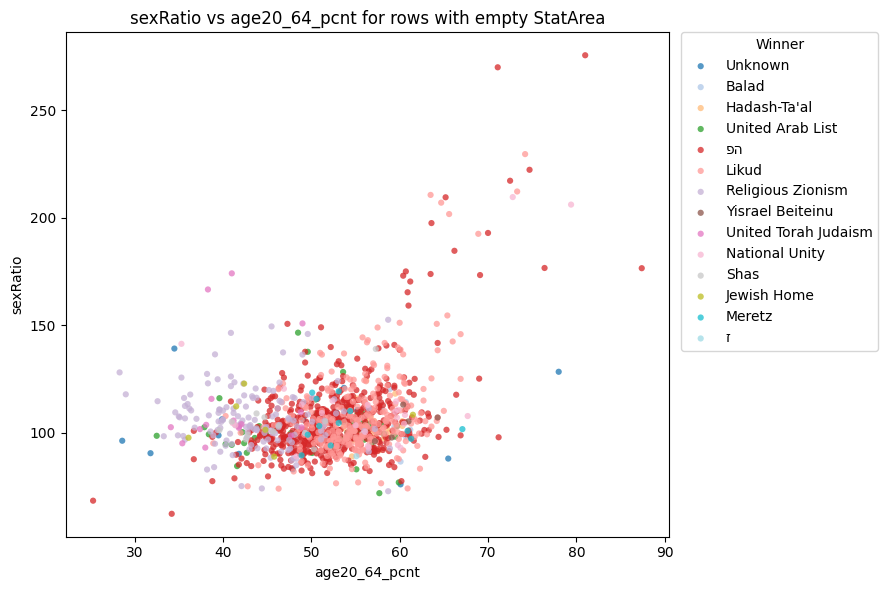

In [ ]:
# ...existing code...
import pandas as pd
import matplotlib.pyplot as plt

# Preconditions
for _df_name in ("census_df", "city_percent"):
    if _df_name not in globals():
        raise RuntimeError(f"Missing {_df_name}.")
for _col in ("StatArea", "LocalityCode", "sexRatio", "age20_64_pcnt"):
    if _col not in census_df.columns:
        raise RuntimeError(f"census_df missing column '{_col}'.")
if not {"city", "winner"}.issubset(set(city_percent.columns)):
    raise RuntimeError("city_percent must have 'city' and 'winner' columns.")

def _norm_key(v):
    if pd.isna(v):
        return None
    s = str(v).strip()
    try:
        f = float(s)
        return str(int(f)) if f.is_integer() else s
    except Exception:
        return s

# Filter rows with empty StatArea
mask_empty = census_df["StatArea"].isna() | (census_df["StatArea"].astype(str).str.strip() == "")
df_plot = census_df.loc[mask_empty].copy()

# Map LocalityCode -> winner from city_percent
cp = city_percent.loc[:, ["city", "winner"]].dropna(subset=["city"]).copy()
cp["_city_key"] = cp["city"].map(_norm_key)
cp = cp.dropna(subset=["_city_key"])
# Keep first non-null winner per city key
cp = cp.sort_values(by=["_city_key"]).drop_duplicates(subset=["_city_key"], keep="first")
city_to_winner = cp.set_index("_city_key")["winner"].to_dict()

df_plot["_city_key"] = df_plot["LocalityCode"].map(_norm_key)
df_plot["winner"] = df_plot["_city_key"].map(city_to_winner).fillna("Unknown")

# Ensure numeric x/y and drop rows without them
df_plot["age20_64_pcnt"] = pd.to_numeric(df_plot["age20_64_pcnt"], errors="coerce")
df_plot["sexRatio"] = pd.to_numeric(df_plot["sexRatio"], errors="coerce")
df_plot = df_plot.dropna(subset=["age20_64_pcnt", "sexRatio"]).copy()

# Build a color palette for unique winners
winners = df_plot["winner"].astype(str).unique().tolist()
colors = plt.cm.get_cmap("tab20", len(winners)).colors if len(winners) > 0 else []

# Plot
plt.figure(figsize=(9, 6))
for i, w in enumerate(winners):
    sub = df_plot[df_plot["winner"] == w]
    plt.scatter(
        sub["age20_64_pcnt"],
        sub["sexRatio"],
        s=20,
        alpha=0.75,
        color=colors[i] if len(colors) > i else None,
        label=w,
        edgecolors="none",
    )

plt.xlabel("age20_64_pcnt")
plt.ylabel("sexRatio")
plt.title("sexRatio vs age20_64_pcnt for rows with empty StatArea")
if winners:
    plt.legend(title="Winner", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
plt.tight_layout()
plt.show()
# ...existing code...

In [ ]:
# ...existing code...
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# Preconditions
for name in ("census_df", "area_results", "city_results"):
    if name not in globals():
        raise RuntimeError(f"Missing required DataFrame: {name}")

# Helpers
def _norm_key(v):
    if pd.isna(v):
        return None
    s = str(v).strip()
    try:
        f = float(s)
        return str(int(f)) if f.is_integer() else s
    except Exception:
        return s

def _to_num(x):
    if isinstance(x, pd.DataFrame):
        return x.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    else:  # Series, array, or scalar
        return pd.to_numeric(x, errors="coerce").fillna(0.0)

# Resolve area_results structure
ar_cols = list(area_results.columns)
if len(ar_cols) < 3:
    raise RuntimeError("area_results must have at least 3 columns (city, area, metrics...).")
# Try to detect city/area columns by name; fallback to first two
city_col_ar = next((c for c in ar_cols[:2] if c.lower() == "city"), ar_cols[0])
area_col_ar = next((c for c in ar_cols[:2] if c.lower() == "area"), ar_cols[1])
ar_metric_cols = [c for c in ar_cols if c not in (city_col_ar, area_col_ar)]

# Normalize keys and ensure numeric metrics
_ar = area_results.copy()
_ar[city_col_ar] = _ar[city_col_ar].map(_norm_key)
_ar[area_col_ar] = _ar[area_col_ar].map(_norm_key)
_ar[ar_metric_cols] = _to_num(_ar[ar_metric_cols])

# Precompute per-(city, area) metric shares and denominators
_ar["__row_sum__"] = _ar[ar_metric_cols].sum(axis=1).replace(0.0, np.nan)
# Dictionary: (city, area) -> (Series metrics row, denom)
ar_row_map = {}
for _, r in _ar.iterrows():
    key = (r[city_col_ar], r[area_col_ar])
    ar_row_map[key] = (r[ar_metric_cols], float(r["__row_sum__"]) if pd.notna(r["__row_sum__"]) else 0.0)

# Resolve city_results structure: city at col index 2, metrics from col index 8 onward (0-based)
cr_cols = list(city_results.columns)
if len(cr_cols) <= 7:
    raise RuntimeError("city_results must have at least 8 columns (city at idx 2, metrics from idx 7).")
city_results_city_col = cr_cols[2]
cr_metric_cols = cr_cols[7:]

_cr = city_results.copy()
_cr[city_results_city_col] = _cr[city_results_city_col].map(_norm_key)
_cr[cr_metric_cols] = _to_num(_cr[cr_metric_cols])

# Precompute per-city metric shares and denominators
_cr["__row_sum__"] = _cr[cr_metric_cols].sum(axis=1).replace(0.0, np.nan)
cr_row_map = {}
for _, r in _cr.iterrows():
    key = r[city_results_city_col]
    cr_row_map[key] = (r[cr_metric_cols], float(r["__row_sum__"]) if pd.notna(r["__row_sum__"]) else 0.0)

# Precompute city multipliers by scanning census_df in order
if not {"LocalityCode", "StatArea", "pop_approx"}.issubset(census_df.columns):
    raise RuntimeError("census_df must include 'LocalityCode', 'StatArea', and 'pop_approx'.")

cdf = census_df.copy()
cdf["_loc"] = cdf["LocalityCode"].map(_norm_key)
cdf["_stat"] = cdf["StatArea"]
cdf["_pop"] = _to_num(cdf["pop_approx"])

city_multiplier = {}
n = len(cdf)
i = 0
while i < n:
    loc = cdf.iloc[i]["_loc"]
    stat_empty = pd.isna(cdf.iloc[i]["_stat"]) or str(cdf.iloc[i]["_stat"]).strip() == ""
    if stat_empty and loc not in city_multiplier:
        # accumulate contiguous block for this locality
        j = i
        total_pop = 0.0
        while j < n and _norm_key(cdf.iloc[j]["LocalityCode"]) == loc:
            total_pop += float(cdf.iloc[j]["_pop"])
            j += 1
        pop_i = float(cdf.iloc[i]["_pop"])
        mult = (pop_i / total_pop) if total_pop > 0 else 0.0
        city_multiplier[loc] = mult
        i = j  # jump to end of block
    else:
        i += 1

# Default multiplier 1.0 for localities not initialized above
# (spec only defines multiplier from the empty StatArea city row; others use stored value)
# We'll not override if missing; we will treat missing as 1.0 in computation.

# Feature columns from the 7th one (0-based index 6)
feature_cols = list(census_df.columns[6:])

# Results matrix: rows = feature columns, cols = area_results metric columns
weighted_avgs = pd.DataFrame(index=feature_cols, columns=ar_metric_cols, dtype=float)

# Main computation with tqdm time tracking
for feat in tqdm(feature_cols, desc="Features", unit="col"):
    x_series = _to_num(census_df[feat])
    for metric in tqdm(ar_metric_cols, desc="Metrics", unit="metric", leave=False):
        sum_w = 0.0
        sum_xw = 0.0
        for idx, row in tqdm(cdf.iterrows(), total=len(cdf), desc=f"Rows [{feat}|{metric}]", unit="row", leave=False):
            x = float(x_series.iloc[idx])
            pop = float(row["_pop"])
            if pop <= 0:
                continue
            loc_key = row["_loc"]
            stat_val = row["_stat"]
            stat_empty = pd.isna(stat_val) or str(stat_val).strip() == ""
            mult = city_multiplier.get(loc_key, 1.0)

            if stat_empty:
                city_metrics, city_denom = cr_row_map.get(loc_key, (None, 0.0))
                if city_metrics is None or city_denom <= 0:
                    continue
                city_val = float(city_metrics.get(metric, 0.0)) if metric in city_metrics.index else 0.0
                w = pop * (city_val / city_denom) * mult
            else:
                area_key = _norm_key(stat_val)
                ar_metrics_row, ar_denom = ar_row_map.get((loc_key, area_key), (None, 0.0))
                if ar_metrics_row is None or ar_denom <= 0:
                    candidates = [v for (c, a), v in ar_row_map.items() if a == area_key]
                    if candidates:
                        ar_metrics_row, ar_denom = candidates[0]
                if ar_metrics_row is None or ar_denom <= 0:
                    continue
                area_val = float(ar_metrics_row.get(metric, 0.0)) if metric in ar_metrics_row.index else 0.0
                w = pop * (area_val / ar_denom) * mult

            if w <= 0:
                continue
            sum_w += w
            sum_xw += x * w

        weighted_avgs.at[feat, metric] = (sum_xw / sum_w) if sum_w > 0 else np.nan

# Result: columns correspond to area_results metrics; rows correspond to census_df feature columns (from 7th)
weighted_avgs  # noqa: F823
# ...existing code...

Features:   0%|          | 0/43 [00:00<?, ?col/s]

Metrics:   0%|          | 0/40 [00:00<?, ?metric/s]

Rows [pop_density|אמת]:   0%|          | 0/3379 [00:00<?, ?row/s]

Rows [pop_density|אצ]:   0%|          | 0/3379 [00:00<?, ?row/s]

Rows [pop_density|ב]:   0%|          | 0/3379 [00:00<?, ?row/s]

...

Rows [rent_pcnt|קץ]:   0%|          | 0/3379 [00:00<?, ?row/s]

Rows [rent_pcnt|רז]:   0%|          | 0/3379 [00:00<?, ?row/s]

Rows [rent_pcnt|שס]:   0%|          | 0/3379 [00:00<?, ?row/s]

Rows [rent_pcnt|ת]:   0%|          | 0/3379 [00:00<?, ?row/s]

,אמת,אצ,ב,ג,ד,ום,ז,זך,זנ,זץ,...,צ,ץ,ק,קי,קך,קנ,קץ,רז,שס,ת
pop_density,0.000000,7557.850643,7108.561418,16840.649179,4459.714180,4402.332909,4408.274051,5381.764608,6952.736386,5850.015567,...,7298.982895,4975.386013,7173.806941,6527.552714,6830.432891,6200.307082,6221.799979,7258.041436,9816.254119,6683.429290
religion,1.264134,1.060462,1.159840,1.008431,1.939306,1.984209,4.470763,1.289879,1.706203,1.373672,...,1.147131,1.786476,1.258361,1.519311,1.291727,2.008650,1.090040,1.187672,1.064360,1.320025
ReligionHeb,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
sexRatio,97.196428,98.943835,100.717372,102.029154,101.803965,101.282509,96.733215,100.332443,99.212791,100.168970,...,98.620264,100.858109,99.298755,99.273137,98.306181,99.830310,99.600036,98.128506,99.715641,98.435897
inst_pcnt,0.000000,1.278661,1.779871,1.989851,0.304274,0.317846,0.127787,0.667230,0.763118,0.719969,...,1.205571,0.505326,1.238647,0.799866,0.966739,0.906147,1.191956,1.564654,1.288300,1.151695
Foreign_pcnt,0.000000,2.077066,1.993753,2.240891,0.468305,0.355733,0.248169,1.734660,1.444668,1.524911,...,1.805431,0.766879,2.016189,1.171344,1.521034,1.267702,2.280482,1.777733,1.799691,1.515823
age0_19_pcnt,33.628688,33.534819,38.190551,46.199092,37.462964,37.516116,37.624117,36.310891,34.329525,34.276099,...,33.466652,36.348168,33.396145,37.778814,33.767041,34.093754,33.327524,32.742595,38.618890,35.449086
age20_64_pcnt,53.163462,53.109602,50.668114,45.557797,55.243381,55.022042,56.125650,52.851984,54.329139,53.721829,...,53.067288,54.639673,53.551456,52.324330,53.251490,54.491053,53.072151,53.036475,50.098563,52.046758
age65_pcnt,13.208890,13.373556,11.158152,8.261797,7.298502,7.467348,6.244273,10.846500,11.343647,12.013335,...,13.475171,9.016419,13.065334,9.901484,12.987324,11.420276,13.612072,14.227542,11.296587,12.510003
DependencyRatio,902.919420,900.925898,1003.626323,1240.793116,818.632599,829.189077,786.585781,918.207213,856.586836,873.516622,...,902.264619,843.658719,885.391495,936.503186,893.418206,851.727014,901.689270,899.158183,1032.415140,945.245311


In [48]:
print(weighted_avgs)

                              אמת            אצ             ב             ג  \
pop_density              0.000000   7557.850643   7108.561418  16840.649179   
religion                 1.264134      1.060462      1.159840      1.008431   
ReligionHeb              0.000000      0.000000      0.000000      0.000000   
sexRatio                97.196428     98.943835    100.717372    102.029154   
inst_pcnt                0.000000      1.278661      1.779871      1.989851   
Foreign_pcnt             0.000000      2.077066      1.993753      2.240891   
age0_19_pcnt            33.628688     33.534819     38.190551     46.199092   
age20_64_pcnt           53.163462     53.109602     50.668114     45.557797   
age65_pcnt              13.208890     13.373556     11.158152      8.261797   
DependencyRatio        902.919420    900.925898   1003.626323   1240.793116   
age_median              33.013355     32.277052     28.694364     22.879708   
m_age_median            31.482237     30.909537     

In [49]:
trans_dict = {
    'מחל': 'Likud',
    'פהת': 'Yesh Atid',
    'ט': 'Religious Zionism',
    'כן': 'National Unity',
    'שס': 'Shas',
    'ג': 'United Torah Judaism',
    'ל': 'Yisrael Beiteinu',
    'עם': 'United Arab List',
    'ום': 'Hadash-Ta\'al',
    'אמת': 'Labor',
    'מרצ': 'Meretz',
    'ד': 'Balad',
    'ב': 'Jewish Home'
}
order = [
    'Likud',
    'Yesh Atid',
    'Religious Zionism',
    'National Unity',
    'Shas',
    'United Torah Judaism',
    'Yisrael Beiteinu',
    'United Arab List',
    'Hadash-Ta\'al',
    'Labor',
    'Meretz',
    'Balad',
    'Jewish Home'
]
col_map = {c: trans_dict[c] for c in weighted_avgs.columns if c in trans_dict}
results = weighted_avgs.loc[:, list(col_map.keys())].rename(columns=col_map).copy()

# 2) Merge potential duplicate target names by summing
results = results.T.groupby(level=0).sum().T

# 3) Sort columns according to 'order' list (extras appended)
if "order" in globals() and isinstance(order, (list, tuple)):
    ordered = [c for c in order if c in results.columns]
    extras = [c for c in results.columns if c not in ordered]
    results = results.loc[:, ordered + extras]
print(results)

                             Likud  Religious Zionism  National Unity  \
pop_density            6972.539594        7352.271528     6538.632535   
religion                  1.083427           1.031793        1.277334   
ReligionHeb               0.000000           0.000000        0.000000   
sexRatio                 98.745122         100.581237       99.516306   
inst_pcnt                 1.169783           1.655029        1.109192   
Foreign_pcnt              1.877998           1.780410        2.266216   
age0_19_pcnt             33.230499          38.111830       32.512211   
age20_64_pcnt            53.112904          50.566135       53.756158   
age65_pcnt               13.667419          11.336173       13.743963   
DependencyRatio         898.940827        1010.589261      876.210250   
age_median               32.498525          28.854008       33.393955   
m_age_median             31.173603          27.862551       31.976307   
w_age_median             33.649285          29.7002

In [54]:
print(results['United Torah Judaism'])

pop_density             16840.649179
religion                    1.008431
ReligionHeb                 0.000000
sexRatio                  102.029154
inst_pcnt                   1.989851
Foreign_pcnt                2.240891
age0_19_pcnt               46.199092
age20_64_pcnt              45.557797
age65_pcnt                  8.261797
DependencyRatio          1240.793116
age_median                 22.879708
m_age_median               22.174968
w_age_median               23.416990
married18_34_pcnt          51.358222
married45_54_pcnt          83.461582
j_isr_pcnt                 82.464734
j_abr_pcnt                 16.791362
aliya2002_pcnt             31.084866
aliya2010_pcnt             18.858550
israel_pcnt                58.627152
asia_pcnt                   5.840500
africa_pcnt                 8.740107
europe_pcnt                18.870645
america_pcnt                7.189394
shem_eretz1                 0.000000
MarriageAge_mdn            22.795346
m_MarriageAge_mdn          23.698622
w

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index, rotation=45, ha="right")


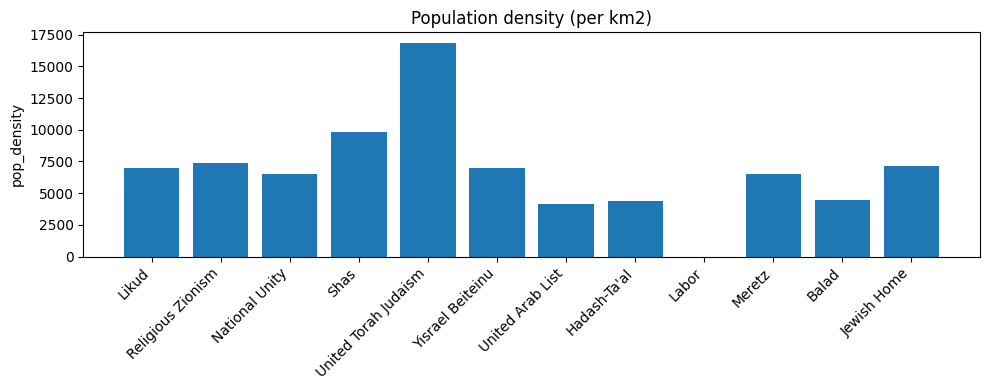

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index, rotation=45, ha="right")


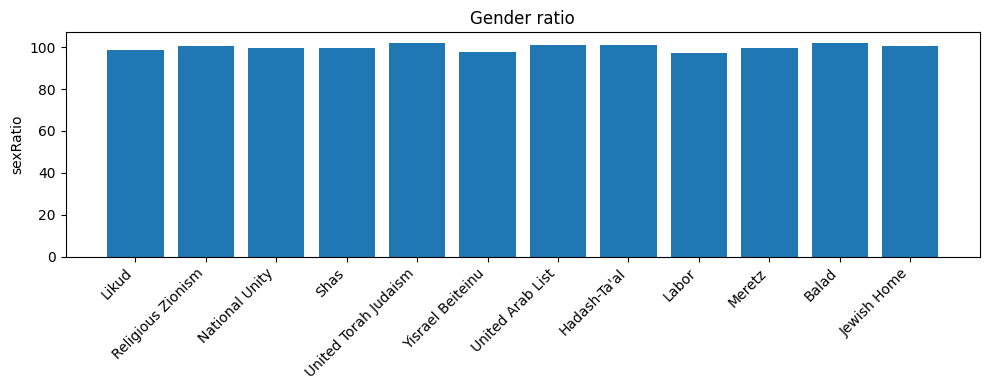

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index, rotation=45, ha="right")


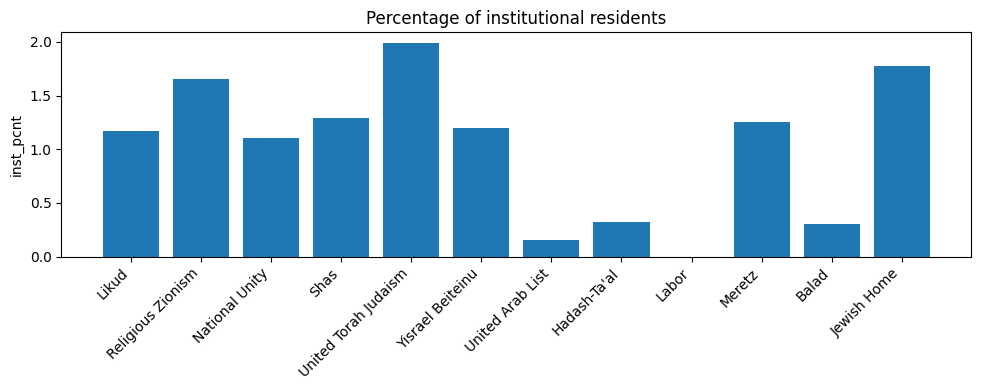

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index, rotation=45, ha="right")


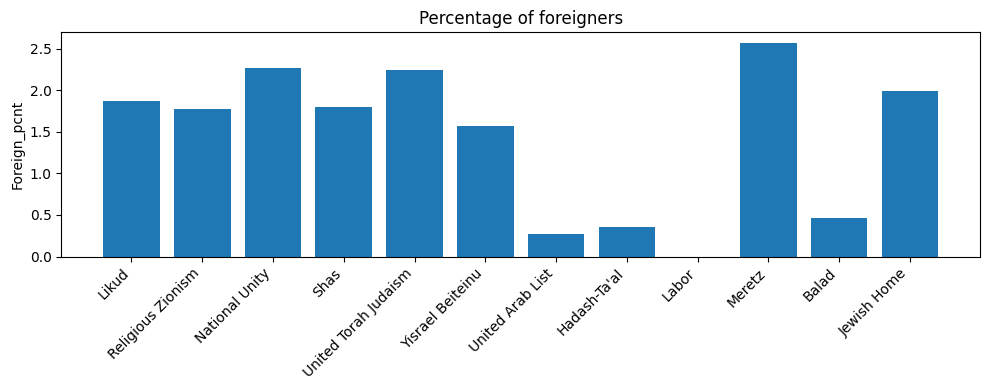

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", m if m <= 10 else 10)


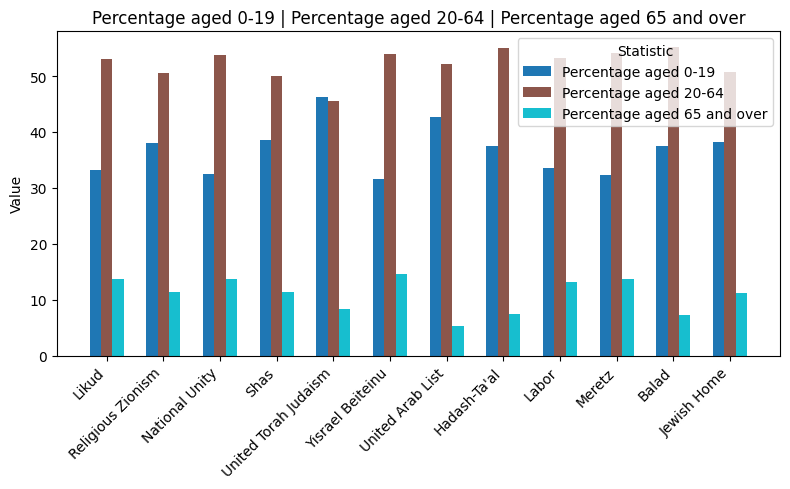

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index, rotation=45, ha="right")


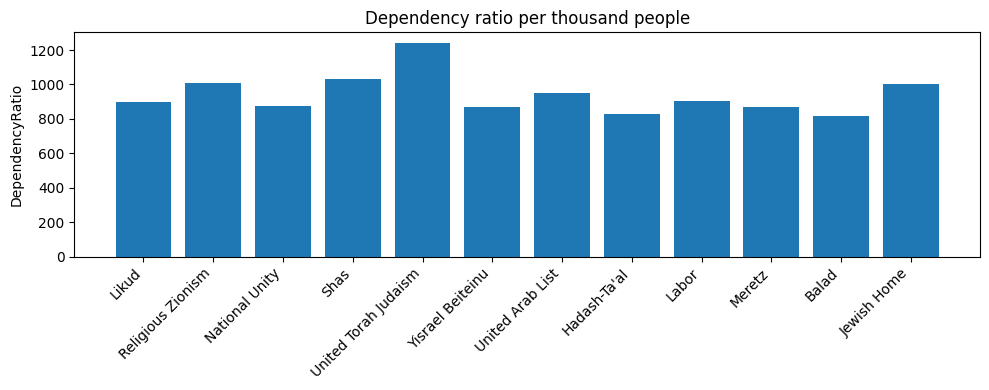

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", m if m <= 10 else 10)


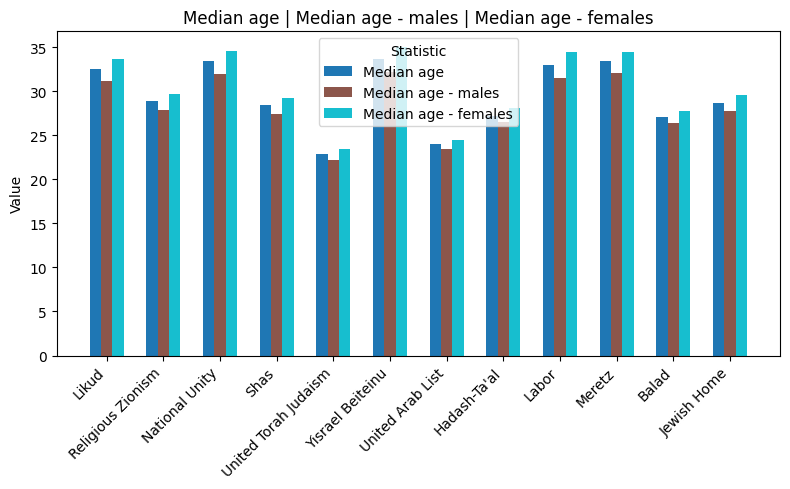

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", m if m <= 10 else 10)


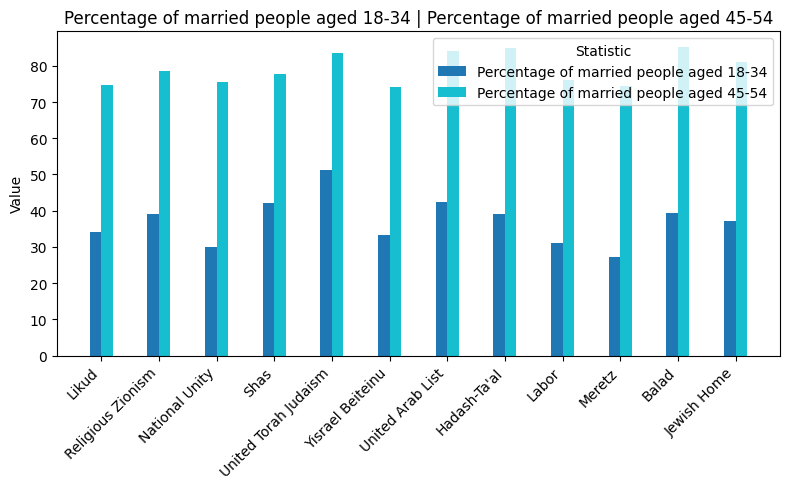

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", m if m <= 10 else 10)


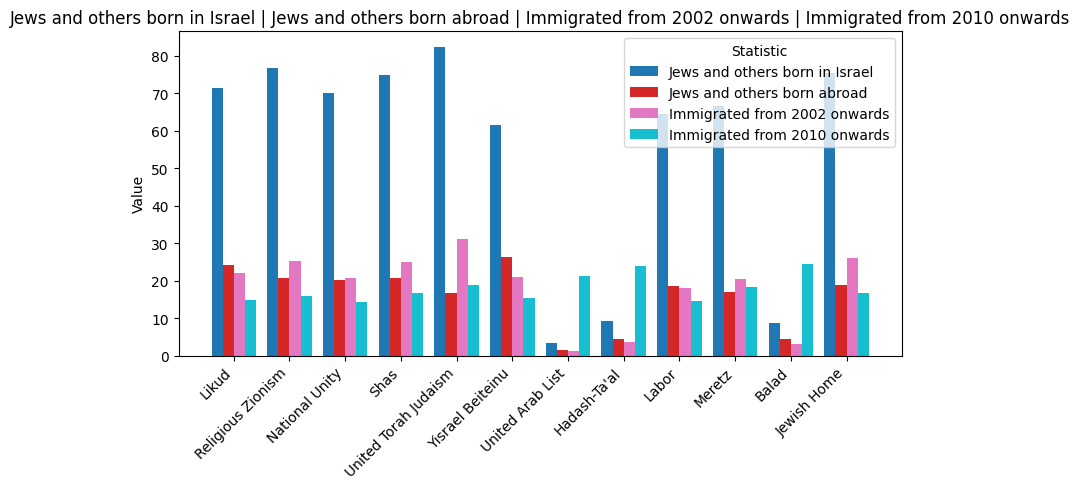

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", m if m <= 10 else 10)


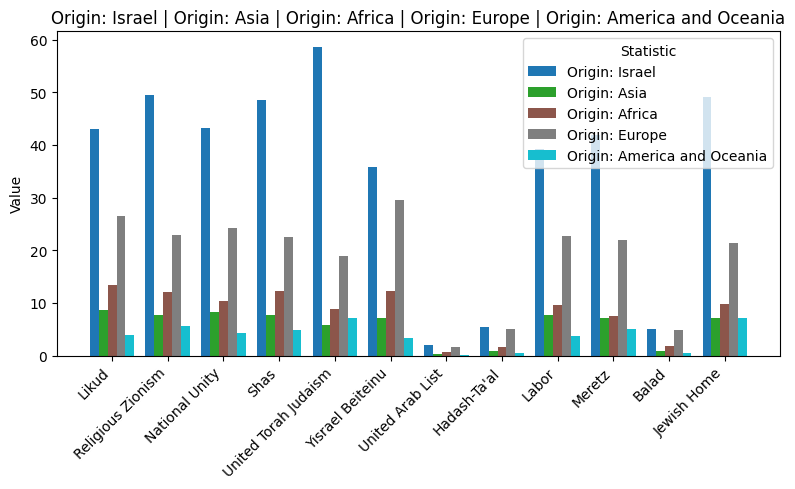

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", m if m <= 10 else 10)


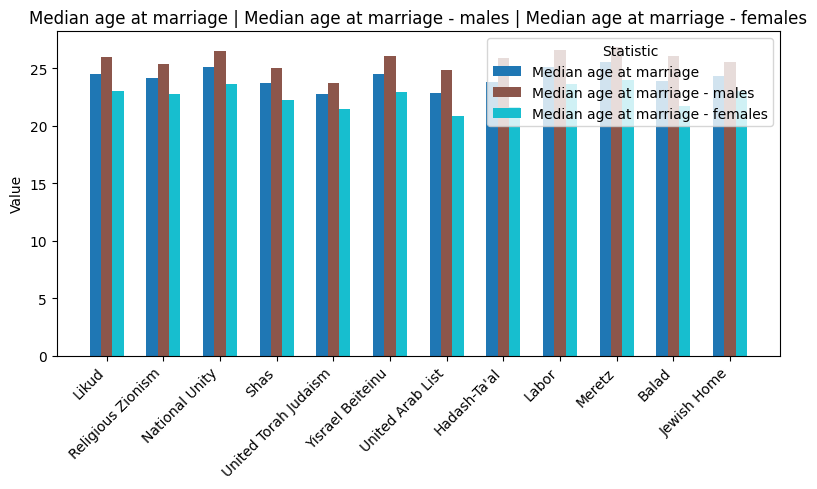

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index, rotation=45, ha="right")


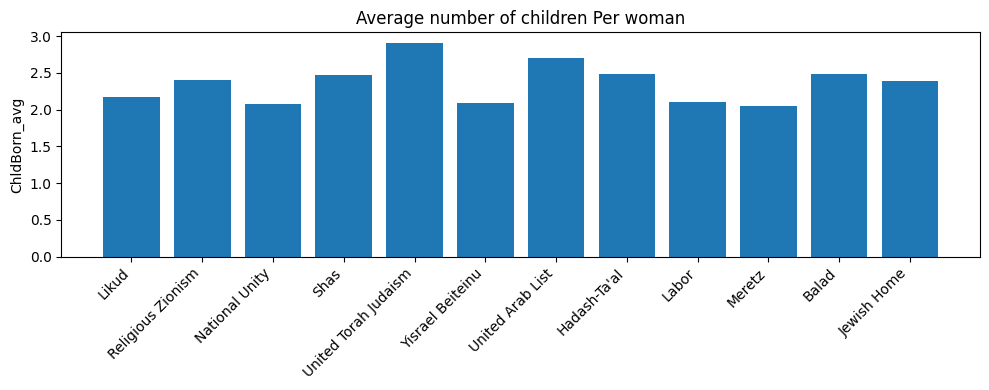

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", m if m <= 10 else 10)


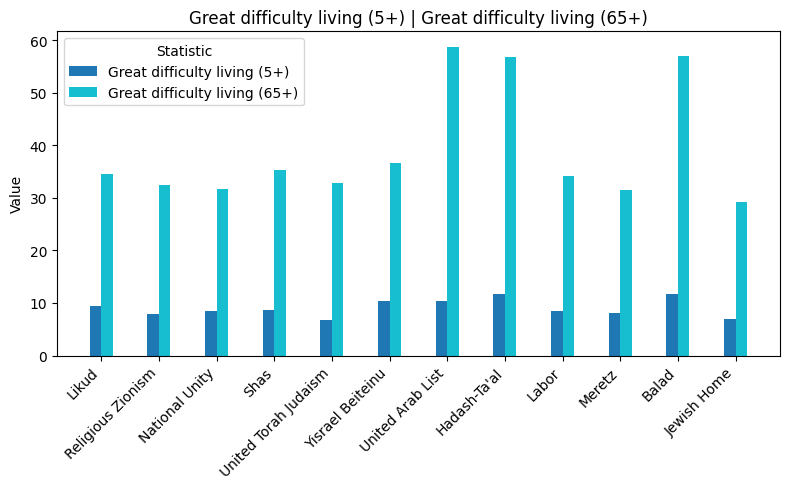

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index, rotation=45, ha="right")


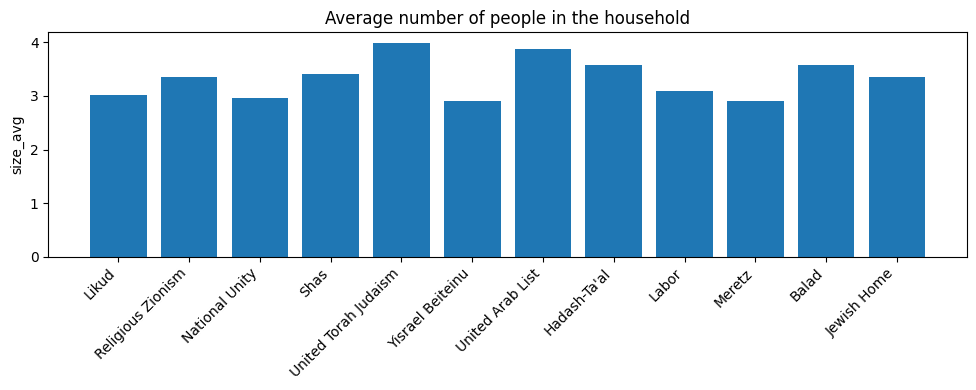

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", m if m <= 10 else 10)


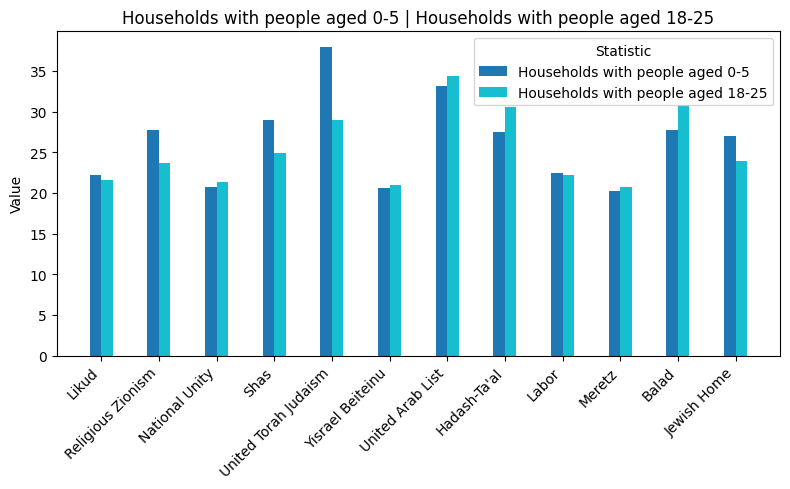

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index, rotation=45, ha="right")


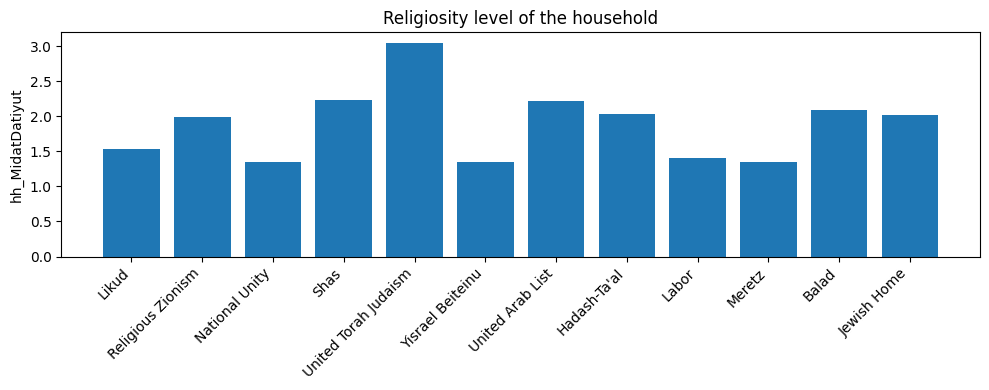

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index, rotation=45, ha="right")


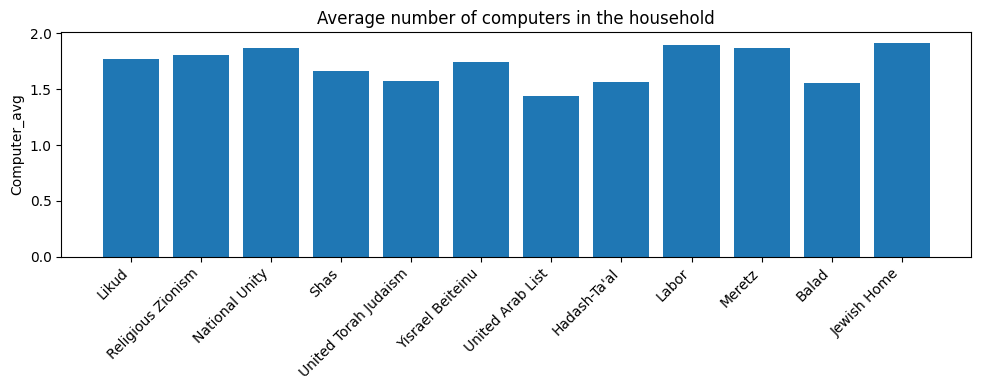

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", m if m <= 10 else 10)


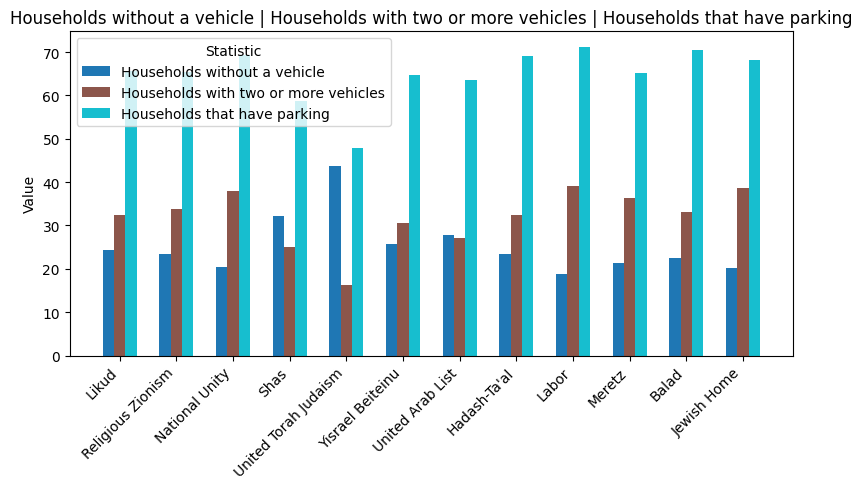

C:\Users\roflm\AppData\Local\Temp\ipykernel_14188\3648539736.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", m if m <= 10 else 10)


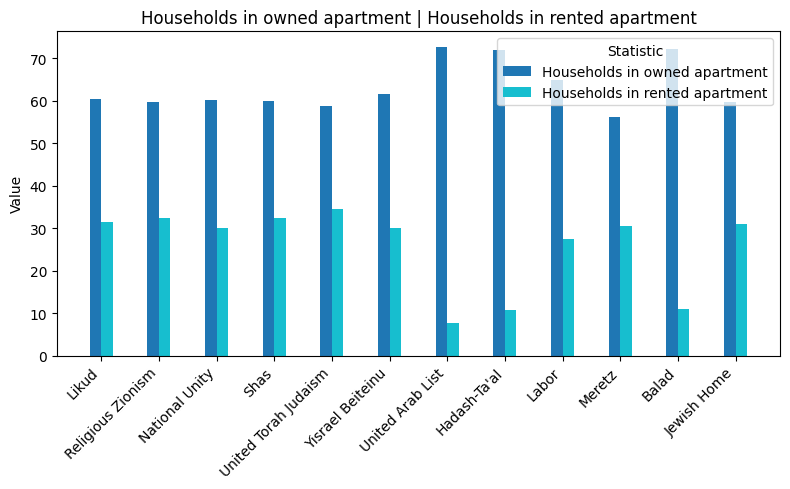

In [51]:
# ...existing code...
import matplotlib.pyplot as plt
import pandas as pd

if "results" not in globals():
    raise RuntimeError("results DataFrame not found.")

# Instructions: tuples are single plots; lists of tuples are grouped in one figure
entries = [
    ("pop_density", "Population density (per km2)"),
    ("sexRatio", "Gender ratio"),
    ("inst_pcnt", "Percentage of institutional residents"),
    ("Foreign_pcnt", "Percentage of foreigners"),
    [
        ("age0_19_pcnt", "Percentage aged 0-19"),
        ("age20_64_pcnt", "Percentage aged 20-64"),
        ("age65_pcnt", "Percentage aged 65 and over"),
    ],
    ("DependencyRatio", "Dependency ratio per thousand people"),
    [
        ("age_median", "Median age"),
        ("m_age_median", "Median age - males"),
        ("w_age_median", "Median age - females"),
    ],
    [
        ("married18_34_pcnt", "Percentage of married people aged 18-34"),
        ("married45_54_pcnt", "Percentage of married people aged 45-54"),
    ],
    [
        ("j_isr_pcnt", "Jews and others born in Israel"),
        ("j_abr_pcnt", "Jews and others born abroad"),
        ("aliya2002_pcnt", "Immigrated from 2002 onwards"),
        ("aliya2010_pcnt", "Immigrated from 2010 onwards"),
    ],
    [
        ("israel_pcnt", "Origin: Israel"),
        ("asia_pcnt", "Origin: Asia"),
        ("africa_pcnt", "Origin: Africa"),
        ("europe_pcnt", "Origin: Europe"),
        ("america_pcnt", "Origin: America and Oceania"),
    ],
    [
        ("MarriageAge_mdn", "Median age at marriage"),
        ("m_MarriageAge_mdn", "Median age at marriage - males"),
        ("w_MarriageAge_mdn", "Median age at marriage - females"),
    ],
    ("ChldBorn_avg", "Average number of children Per woman"),
    [
        ("koshi5_pcnt", "Great difficulty living (5+)"),
        ("koshi65_pcnt", "Great difficulty living (65+)"),
    ],
    ("size_avg", "Average number of people in the household"),
    [
        ("hh0_5_pcnt", "Households with people aged 0-5"),
        ("hh18_24_pcnt", "Households with people aged 18-25"),
    ],
    ("hh_MidatDatiyut", "Religiosity level of the household"),
    ("Computer_avg", "Average number of computers in the household"),
    [
        ("Vehicle0_pcnt", "Households without a vehicle"),
        ("Vehicle2up_pcnt", "Households with two or more vehicles"),
        ("Parking_pcnt", "Households that have parking"),
    ],
    [
        ("own_pcnt", "Households in owned apartment"),
        ("rent_pcnt", "Households in rented apartment"),
    ],
]

def _plot_single(ax, key: str, title: str):
    if key not in results.index:
        ax.set_visible(False)
        return False
    s = pd.to_numeric(results.loc[key], errors="coerce").fillna(0.0)
    ax.bar(s.index, s.values)
    ax.set_title(title)
    ax.set_ylabel(key)
    ax.set_xticklabels(s.index, rotation=45, ha="right")
    return True

def _plot_group_grouped_bars(group):
    # group: list of (key, title)
    party_cols = list(results.columns)
    # Only keep keys that exist
    keys = [(k, t) for (k, t) in group if k in results.index]
    if not keys:
        return
    m = len(keys)
    n = len(party_cols)
    x = np.arange(n)

    # Colors: consistent per statistic
    cmap = plt.cm.get_cmap("tab10", m if m <= 10 else 10)
    colors = [cmap(i % cmap.N) for i in range(m)]

    # Collect data per stat over parties
    vals = []
    labels = []
    for k, t in keys:
        s = pd.to_numeric(results.loc[k, party_cols], errors="coerce").fillna(0.0)
        vals.append(s.to_numpy(dtype=float))
        labels.append(t)

    # Bar width so all stats fit within each party cluster
    width = min(0.8 / m, 0.2)
    total_width = width * m

    fig, ax = plt.subplots(figsize=(max(8, n * 0.5), 5))
    for i in range(m):
        offsets = x - total_width / 2 + i * width + width / 2
        ax.bar(offsets, vals[i], width=width, label=labels[i], color=colors[i])

    ax.set_xticks(x)
    ax.set_xticklabels(party_cols, rotation=45, ha="right")
    ax.set_ylabel("Value")
    ax.set_title(" | ".join(labels))
    ax.legend(title="Statistic")
    plt.tight_layout()
    plt.show()

# entries defined earlier (list of tuples and lists)
for item in entries:
    if isinstance(item, tuple):
        fig, ax = plt.subplots(figsize=(10, 4))
        ok = _plot_single(ax, item[0], item[1])
        if ok:
            plt.tight_layout()
            plt.show()
        else:
            plt.close(fig)
    else:
        _plot_group_grouped_bars(item)